In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import affine_transform
from matplotlib.patches import Rectangle

In [5]:
SIZE = 15

# pixel coords for shapes
SHAPES = {
    'triangle': [(2,4),(3,3),(3,4),(3,5),(4,4)],
    'circle':   [(9,10),(9,11),(10,9),(10,12),(11,9),(11,12),(12,10),(12,11)],
    'square':   [(4,11),(4,12),(5,11),(5,12)]
}

# triangle→red, circle→blue, square→green (one-hot channels: R,G,B)
COLOR_MAP = {'triangle': (1,0,0), 'circle': (0,0,1), 'square': (0,1,0)}

TITLE_SIZE = 22

In [9]:
def create_image_rgb(size, shapes_to_draw):
    img = np.ones((size, size, 3), dtype=float)   
    for name in shapes_to_draw:
        r,g,b = COLOR_MAP[name]
        for r0,c0 in SHAPES[name]:
            if 0 <= r0 < size and 0 <= c0 < size:
                img[r0, c0, 0] = r
                img[r0, c0, 1] = g
                img[r0, c0, 2] = b
    return img


def warp_rgb(img_rgb, offset):
    out = np.zeros_like(img_rgb)
    for ch in range(3):
        out[..., ch] = affine_transform(
            img_rgb[..., ch],
            matrix=np.eye(2),
            offset=offset,
            output_shape=img_rgb.shape[:2],
            order=1,
            mode='constant',
            cval=1.0                   
        )
    return np.clip(out, 0.0, 1.0)


def plot_image_with_grid(ax, img_rgb, title):
    ax.imshow(img_rgb, origin='upper')
    ax.set_title(title, fontsize=TITLE_SIZE)
    ax.set_xticks(np.arange(0, SIZE, 1))
    ax.set_yticks(np.arange(0, SIZE, 1))
    ax.set_xticks(np.arange(-.5, SIZE, 1), minor=True)
    ax.set_yticks(np.arange(-.5, SIZE, 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)
    #ax.set_xlabel('Column (c)', fontsize=8)
    #ax.set_ylabel('Row (r)', fontsize=8)

## 1. Initial Images (Fixed and Moving) - Sub-pixel Shift


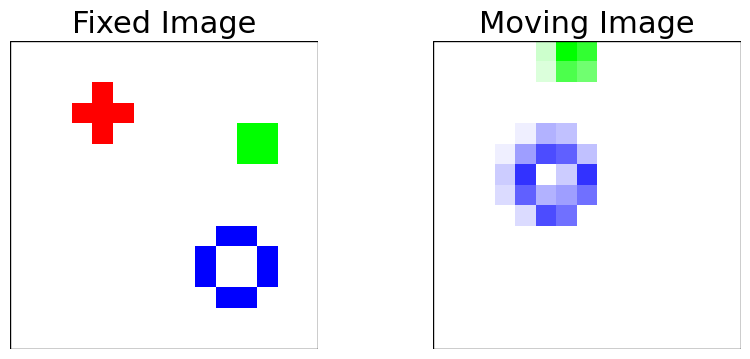

---
## 2. Registration with Interpolation


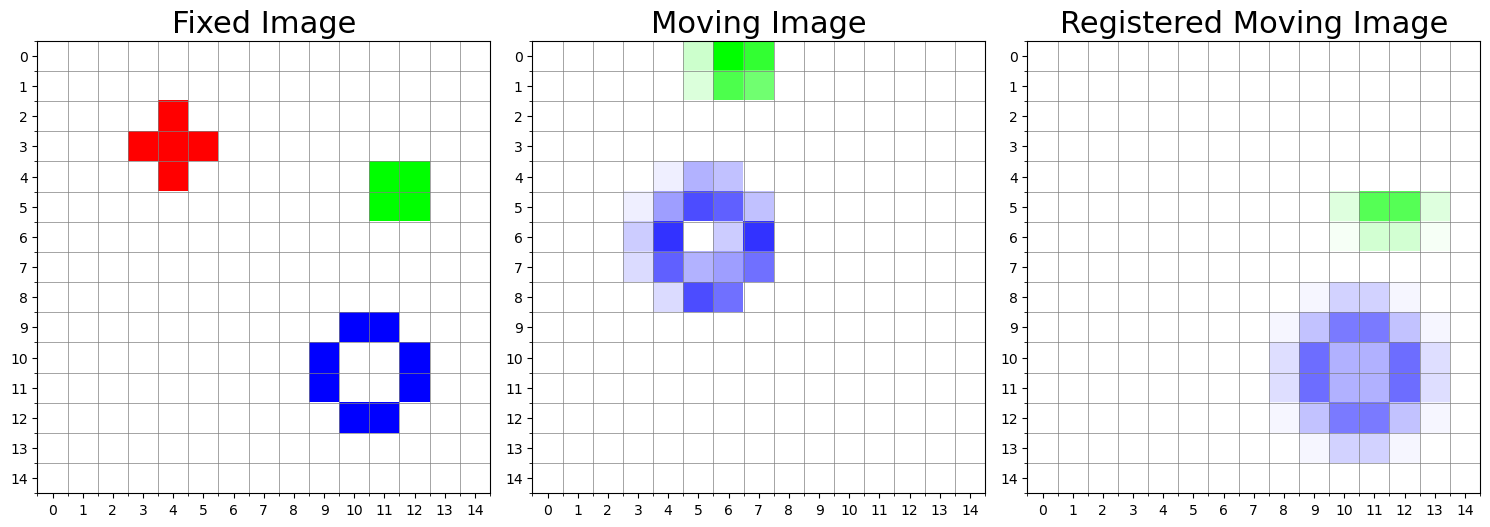


Key point: interpolation happens within each color channel, so shapes stay red/blue/green with varying intensity, not mixed hues.


In [10]:
# --- Build images ---
fixed_rgb = create_image_rgb(SIZE, ['triangle','circle','square'])

R_SHIFT, C_SHIFT = 4.3, 5.2
moving_aligned_rgb = create_image_rgb(SIZE, ['circle','square'])
moving_rgb = warp_rgb(moving_aligned_rgb, offset=(R_SHIFT, C_SHIFT))           # misaligned
registered_rgb = warp_rgb(moving_rgb, offset=(-R_SHIFT, -C_SHIFT))             # back-aligned

# --- Show images (no mixing of hues; edges are soft within each shape's own hue) ---
print("## 1. Initial Images (Fixed and Moving) - Sub-pixel Shift")
plt.figure(figsize=(10,4))
ax1 = plt.subplot(1,2,1); ax1.imshow(fixed_rgb); ax1.set_title('Fixed Image', size=TITLE_SIZE); ax1.axis('off')
ax2 = plt.subplot(1,2,2); ax2.imshow(moving_rgb); ax2.set_title('Moving Image', size=TITLE_SIZE); ax2.axis('off')

ax1.set_xticks([]); ax1.set_yticks([])
ax1.add_patch(Rectangle((-0.5,-0.5), SIZE, SIZE, fill=False, linewidth=1, edgecolor='black'))  

ax2.set_xticks([]); ax1.set_yticks([])
ax2.add_patch(Rectangle((-0.5,-0.5), SIZE, SIZE, fill=False, linewidth=1, edgecolor='black'))  
plt.savefig('../static/img/fixed_moving.png')
plt.show()

print("---\n## 2. Registration with Interpolation")
plt.figure(figsize=(15,6))
plot_image_with_grid(plt.subplot(1,3,1), fixed_rgb, 'Fixed Image')
plot_image_with_grid(plt.subplot(1,3,2), moving_rgb, 'Moving Image')
plot_image_with_grid(plt.subplot(1,3,3), registered_rgb, 'Registered Moving Image')
plt.tight_layout()
plt.savefig('../static/img/fixed_moving_registered.png')
plt.show()

print("\nKey point: interpolation happens within each color channel, so shapes stay red/blue/green with varying intensity, not mixed hues.")
